# UFC Fight Prediction — Data Exploration

This notebook explores the UFC dataset to understand **the sport itself** before building prediction models. Instead of comparing arbitrary "fighter_1" vs "fighter_2" slots, we focus on:

1. **Dataset overview** — volume, weight classes, how fights end
2. **How fights end** — finishes vs decisions, by era and weight class
3. **Fighter population** — who fights in the UFC (age, physicals, career lengths)
4. **Matchup quality** — how mismatched are fights? (absolute skill gaps)
5. **Favorites vs underdogs** — using Elo to define who *should* win, and when they don't
6. **Predictive signal check** — what actually separates winners from losers?
7. **Missingness & temporal structure** — practical notes for modeling

**Prerequisites:** Run `make features_up` to populate the feature tables before using this notebook.

---

## 1. Setup

In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add repo root to path so we can import project modules
sys.path.insert(0, str(Path.cwd().parent))

from warehouse.db import get_connection
from modeling.data import load_bout_data, temporal_split, rolling_cv, FEATURE_COLS, describe_splits

# Plot style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", "{:.4f}".format)

/home/wlodzimierrr/.local/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
conn = get_connection()

# Model-ready bout features (diff/ratio features)
df = load_bout_data(conn)

# Raw fights table — has finish method, rounds, referee etc.
fights = pd.read_sql("""
    SELECT f.fight_id, f.event_id, f.fighter_1_id, f.fighter_2_id,
           f.result_type, f.weight_class, f.is_title_fight,
           f.scheduled_rounds, f.finish_method, f.finish_round,
           f.finish_time_seconds, e.event_date
    FROM fights f
    JOIN events e ON f.event_id = e.event_id
    WHERE f.result_type = 'win'
    ORDER BY e.event_date
""", conn, parse_dates=["event_date"])

# Fighter snapshots — individual fighter stats per fight (not diffs)
snapshots = pd.read_sql("""
    SELECT fighter_id, fight_id, as_of_date,
           career_fights, career_wins, career_losses, career_win_rate,
           career_finish_rate, career_ko_tko_wins, career_sub_wins, career_dec_wins,
           career_sig_strikes_landed_pm, career_sig_strike_accuracy,
           career_takedown_accuracy, career_control_rate,
           age, height_cm, reach_cm, reach_to_height,
           elo_rating, days_since_last_fight, is_debut,
           win_rate_last3, streak_last3
    FROM fighter_snapshots
    ORDER BY as_of_date
""", conn, parse_dates=["as_of_date"])

conn.close()

print(f"Bout features: {len(df):,} labeled bouts")
print(f"Fights table:  {len(fights):,} wins (excl. draws/NC)")
print(f"Snapshots:     {len(snapshots):,} fighter-fight rows")
print(f"Date range:    {fights['event_date'].min().date()} to {fights['event_date'].max().date()}")

/tmp/ipykernel_149381/239759092.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  fights = pd.read_sql("""
/tmp/ipykernel_149381/239759092.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  snapshots = pd.read_sql("""


Bout features: 8,400 labeled bouts
Fights table:  8,400 wins (excl. draws/NC)
Snapshots:     17,100 fighter-fight rows
Date range:    1994-03-11 to 2026-03-07


## 2. Dataset Overview

How has the UFC grown, and what does the fight landscape look like?

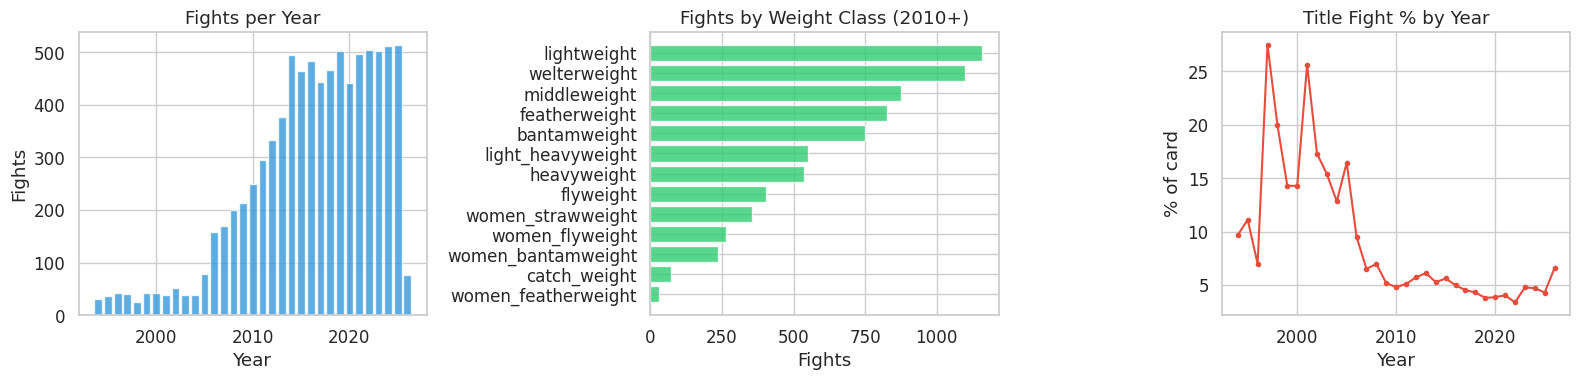

Total fights: 8,400
Weight classes: 15
Title fights: 465 (5.5%)


In [3]:
fights["year"] = fights["event_date"].dt.year

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Fights per year
fights_per_year = fights.groupby("year").size()
axes[0].bar(fights_per_year.index, fights_per_year.values, color="#3498db", alpha=0.8)
axes[0].set_title("Fights per Year")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Fights")

# Weight class distribution (modern era)
modern = fights[fights["year"] >= 2010]
wc_order = modern["weight_class"].value_counts()
axes[1].barh(wc_order.index, wc_order.values, color="#2ecc71", alpha=0.8)
axes[1].set_title("Fights by Weight Class (2010+)")
axes[1].set_xlabel("Fights")
axes[1].invert_yaxis()

# Title fights per year
title_pct = fights.groupby("year")["is_title_fight"].mean() * 100
axes[2].plot(title_pct.index, title_pct.values, "o-", color="#e74c3c", markersize=3)
axes[2].set_title("Title Fight % by Year")
axes[2].set_xlabel("Year")
axes[2].set_ylabel("% of card")

plt.tight_layout()
plt.show()

print(f"Total fights: {len(fights):,}")
print(f"Weight classes: {fights['weight_class'].nunique()}")
print(f"Title fights: {fights['is_title_fight'].sum():,} ({100*fights['is_title_fight'].mean():.1f}%)")

## 3. How Fights End

Finish method tells us about the nature of the sport — is it becoming more technical (decisions) or more violent (KOs)? This matters for modeling because predicting *how* a fight ends is harder than predicting *who* wins.

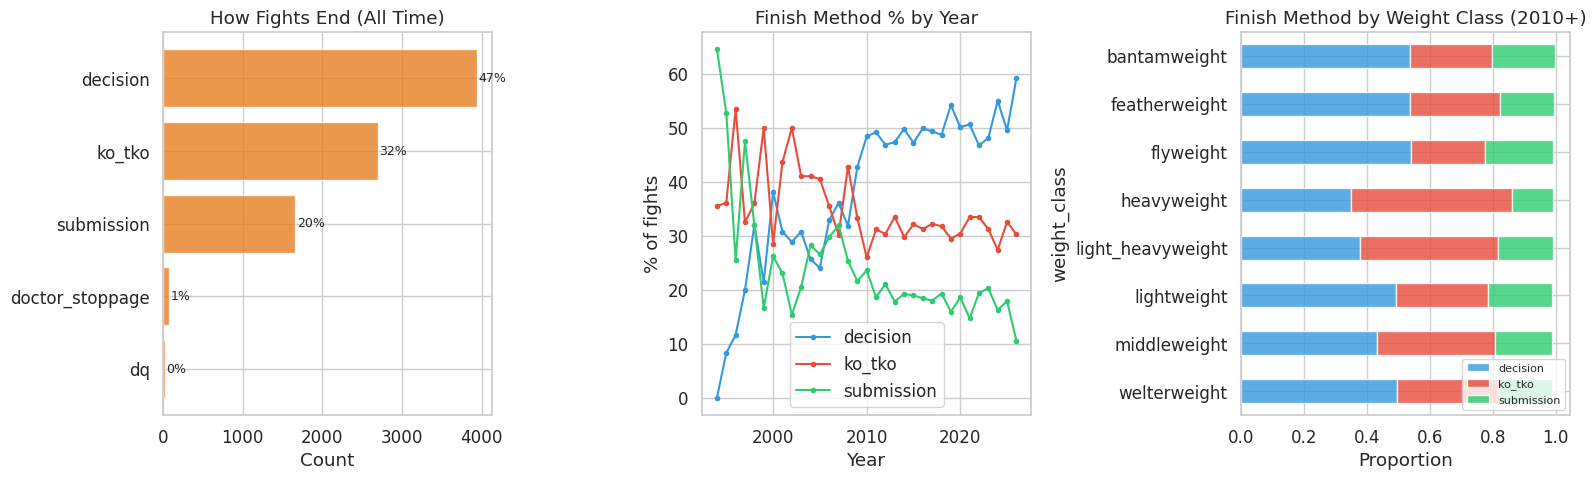


Median finish round: 3
Fights going to decision: 3,939 (46.9%)
First-round finishes: 2,369 (28.2%)


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Overall finish method breakdown
finish_counts = fights["finish_method"].value_counts()
axes[0].barh(finish_counts.index, finish_counts.values, color="#e67e22", alpha=0.8)
axes[0].set_title("How Fights End (All Time)")
axes[0].set_xlabel("Count")
axes[0].invert_yaxis()
for i, (method, count) in enumerate(finish_counts.items()):
    axes[0].text(count + 20, i, f"{100*count/len(fights):.0f}%", va="center", fontsize=9)

# Finish method evolution over time
era_finish = fights.groupby("year")["finish_method"].value_counts(normalize=True).unstack(fill_value=0)
main_methods = ["decision", "ko_tko", "submission"]
for method, color in zip(main_methods, ["#3498db", "#e74c3c", "#2ecc71"]):
    if method in era_finish.columns:
        axes[1].plot(era_finish.index, era_finish[method] * 100, "o-", label=method, color=color, markersize=3)
axes[1].set_title("Finish Method % by Year")
axes[1].set_ylabel("% of fights")
axes[1].set_xlabel("Year")
axes[1].legend()

# Finish method by weight class (modern era)
top_wc = modern["weight_class"].value_counts().head(8).index
wc_finish = modern[modern["weight_class"].isin(top_wc)].groupby("weight_class")["finish_method"].value_counts(normalize=True).unstack(fill_value=0)
wc_finish = wc_finish.reindex(columns=main_methods, fill_value=0)
wc_finish.plot.barh(stacked=True, ax=axes[2], color=["#3498db", "#e74c3c", "#2ecc71"], alpha=0.8)
axes[2].set_title("Finish Method by Weight Class (2010+)")
axes[2].set_xlabel("Proportion")
axes[2].legend(loc="lower right", fontsize=8)
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

# Fight duration
has_time = fights.dropna(subset=["finish_round", "finish_time_seconds"])
print(f"\nMedian finish round: {has_time['finish_round'].median():.0f}")
print(f"Fights going to decision: {(fights['finish_method'] == 'decision').sum():,} ({100*(fights['finish_method'] == 'decision').mean():.1f}%)")
print(f"First-round finishes: {(has_time['finish_round'] == 1).sum():,} ({100*(has_time['finish_round'] == 1).mean():.1f}%)")

## 4. Fighter Population

Who fights in the UFC? Understanding the population of fighters — their age, physical attributes, and career trajectories — tells us what kind of variation the model can exploit.

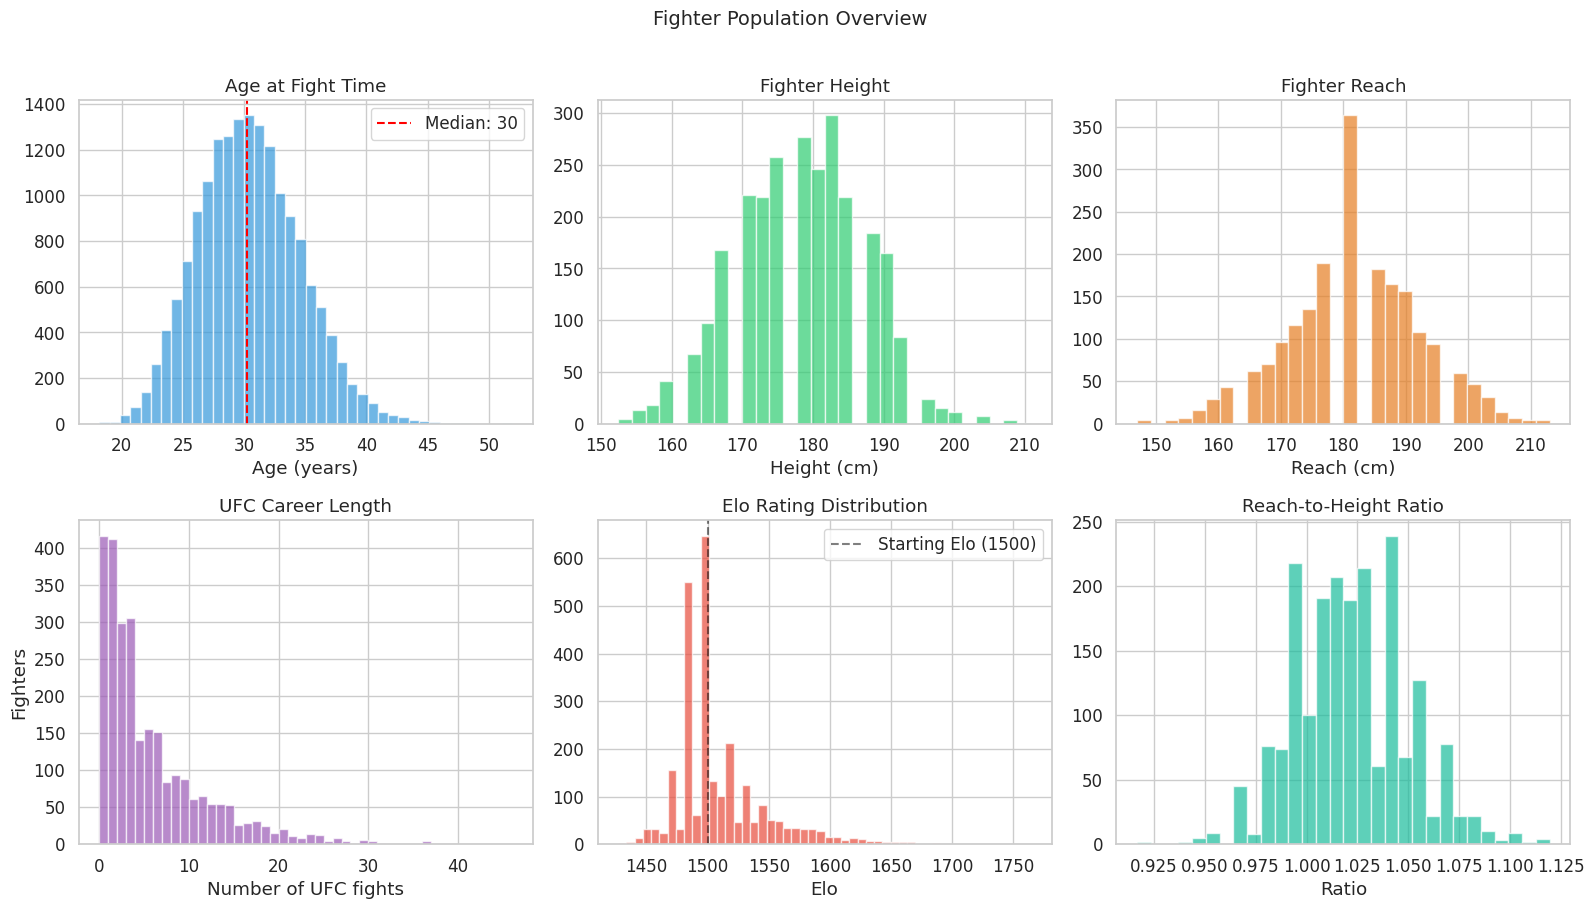

Unique fighters: 2,662
Median age at fight: 30.2 | Mean: 30.4
Median UFC career: 3 fights | Mean: 5.4
Debut fighters (0 prior UFC fights): 416 (15.6%)


In [5]:
# Use snapshots for individual fighter stats (not diffs)
# Take each fighter's latest snapshot as their "current" profile
latest_snap = snapshots.sort_values("as_of_date").drop_duplicates("fighter_id", keep="last")

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Age distribution at time of fight
age_data = snapshots["age"].dropna()
axes[0, 0].hist(age_data, bins=40, color="#3498db", alpha=0.7, edgecolor="white")
axes[0, 0].axvline(age_data.median(), color="red", linestyle="--", label=f"Median: {age_data.median():.0f}")
axes[0, 0].set_title("Age at Fight Time")
axes[0, 0].set_xlabel("Age (years)")
axes[0, 0].legend()

# Height distribution
ht = latest_snap["height_cm"].dropna()
axes[0, 1].hist(ht, bins=30, color="#2ecc71", alpha=0.7, edgecolor="white")
axes[0, 1].set_title("Fighter Height")
axes[0, 1].set_xlabel("Height (cm)")

# Reach distribution
rc = latest_snap["reach_cm"].dropna()
axes[0, 2].hist(rc, bins=30, color="#e67e22", alpha=0.7, edgecolor="white")
axes[0, 2].set_title("Fighter Reach")
axes[0, 2].set_xlabel("Reach (cm)")

# Career length (UFC fights)
career = latest_snap["career_fights"]
axes[1, 0].hist(career, bins=range(0, int(career.max()) + 2), color="#9b59b6", alpha=0.7, edgecolor="white")
axes[1, 0].set_title("UFC Career Length")
axes[1, 0].set_xlabel("Number of UFC fights")
axes[1, 0].set_ylabel("Fighters")

# Elo distribution
elo = latest_snap["elo_rating"].dropna()
axes[1, 1].hist(elo, bins=50, color="#e74c3c", alpha=0.7, edgecolor="white")
axes[1, 1].axvline(1500, color="black", linestyle="--", alpha=0.5, label="Starting Elo (1500)")
axes[1, 1].set_title("Elo Rating Distribution")
axes[1, 1].set_xlabel("Elo")
axes[1, 1].legend()

# Reach-to-height ratio
rth = latest_snap["reach_to_height"].dropna()
axes[1, 2].hist(rth, bins=30, color="#1abc9c", alpha=0.7, edgecolor="white")
axes[1, 2].set_title("Reach-to-Height Ratio")
axes[1, 2].set_xlabel("Ratio")

plt.suptitle("Fighter Population Overview", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print(f"Unique fighters: {latest_snap['fighter_id'].nunique():,}")
print(f"Median age at fight: {age_data.median():.1f} | Mean: {age_data.mean():.1f}")
print(f"Median UFC career: {career.median():.0f} fights | Mean: {career.mean():.1f}")
print(f"Debut fighters (0 prior UFC fights): {(career == 0).sum():,} ({100*(career == 0).mean():.1f}%)")

## 5. Matchup Quality — How Mismatched Are Fights?

The UFC aims for competitive matchups, but skill gaps exist. Using **absolute** differences (not directional fighter_1 - fighter_2) tells us how evenly matched fights really are — regardless of which slot a fighter is in.

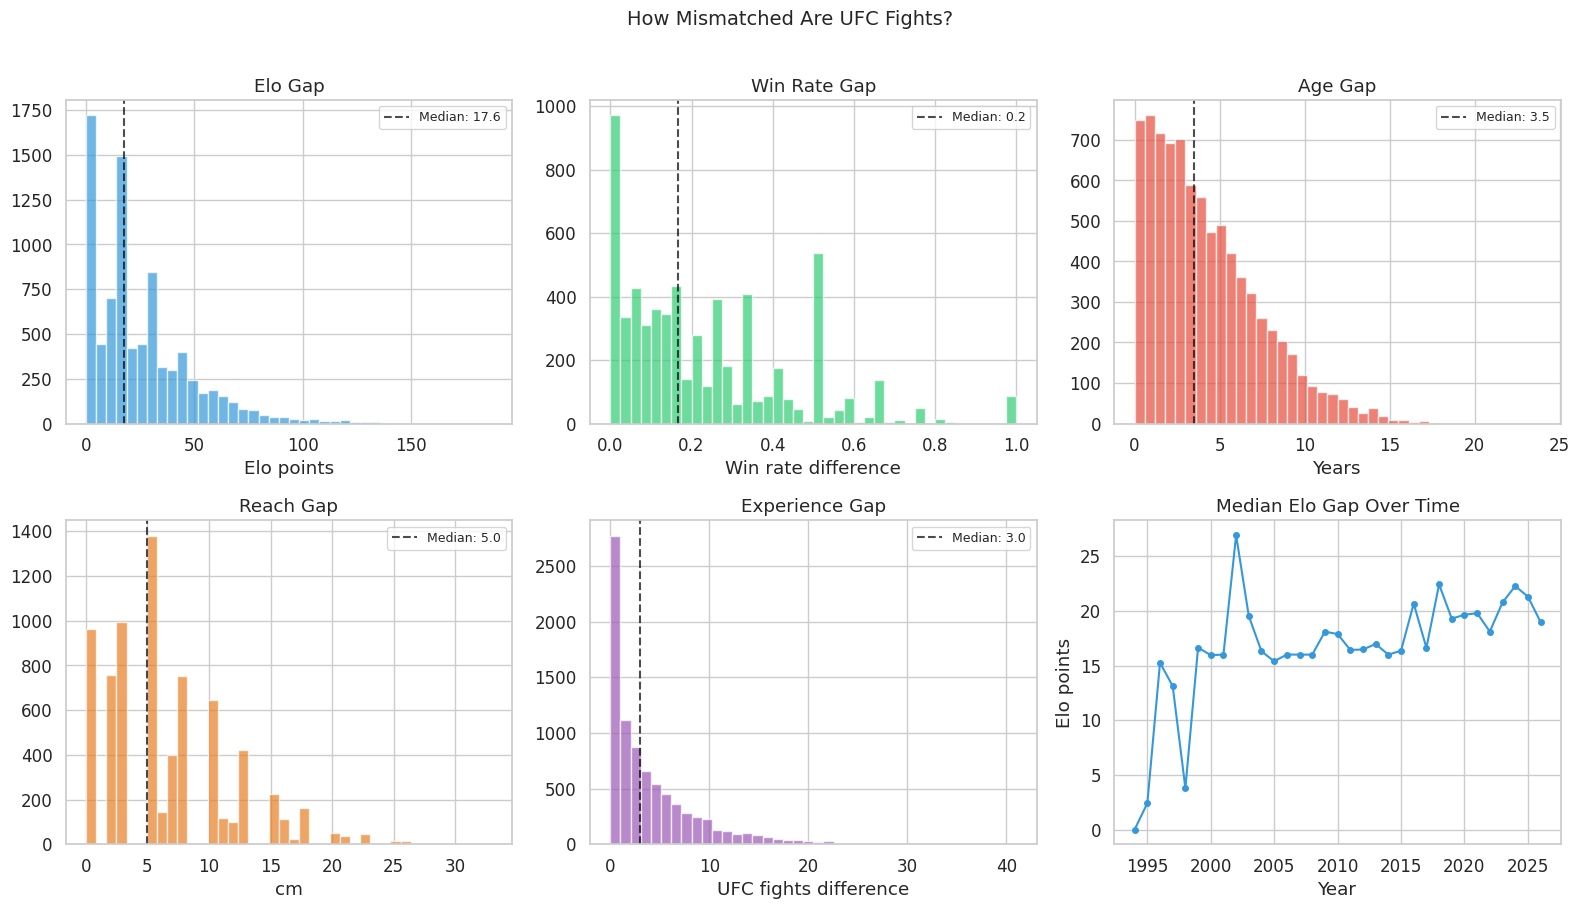

Median Elo gap: 18 points
Fights with Elo gap > 200: 0 (0.0%)
Very close matchups (Elo gap < 50): 7,271 (86.6%)


In [6]:
# Compute absolute gaps — these are position-agnostic
df["abs_elo_gap"] = df["diff_elo"].abs()
df["abs_win_rate_gap"] = df["diff_career_win_rate"].abs()
df["abs_age_gap"] = df["diff_age"].abs()
df["abs_reach_gap"] = df["diff_reach_cm"].abs()
df["abs_experience_gap"] = df["diff_career_fights"].abs()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

gap_configs = [
    ("abs_elo_gap", "Elo Gap", "#3498db", "Elo points"),
    ("abs_win_rate_gap", "Win Rate Gap", "#2ecc71", "Win rate difference"),
    ("abs_age_gap", "Age Gap", "#e74c3c", "Years"),
    ("abs_reach_gap", "Reach Gap", "#e67e22", "cm"),
    ("abs_experience_gap", "Experience Gap", "#9b59b6", "UFC fights difference"),
]

for ax, (col, title, color, xlabel) in zip(axes.flat, gap_configs):
    data = df[col].dropna()
    ax.hist(data, bins=40, color=color, alpha=0.7, edgecolor="white")
    ax.axvline(data.median(), color="black", linestyle="--", alpha=0.7, label=f"Median: {data.median():.1f}")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.legend(fontsize=9)

# Last panel: mismatch trend over time (Elo gap by year)
df["year"] = df["event_date"].dt.year
yearly_gap = df.groupby("year")["abs_elo_gap"].median()
axes[1, 2].plot(yearly_gap.index, yearly_gap.values, "o-", color="#3498db", markersize=4)
axes[1, 2].set_title("Median Elo Gap Over Time")
axes[1, 2].set_xlabel("Year")
axes[1, 2].set_ylabel("Elo points")

plt.suptitle("How Mismatched Are UFC Fights?", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print(f"Median Elo gap: {df['abs_elo_gap'].median():.0f} points")
print(f"Fights with Elo gap > 200: {(df['abs_elo_gap'] > 200).sum():,} ({100*(df['abs_elo_gap'] > 200).mean():.1f}%)")
print(f"Very close matchups (Elo gap < 50): {(df['abs_elo_gap'] < 50).sum():,} ({100*(df['abs_elo_gap'] < 50).mean():.1f}%)")

## 6. Favorites vs Underdogs

Instead of comparing "fighter_1" to "fighter_2" (arbitrary), we use **Elo** to define the **favorite** (higher Elo) and **underdog** (lower Elo). This is a meaningful distinction — how often does the better-rated fighter actually win?

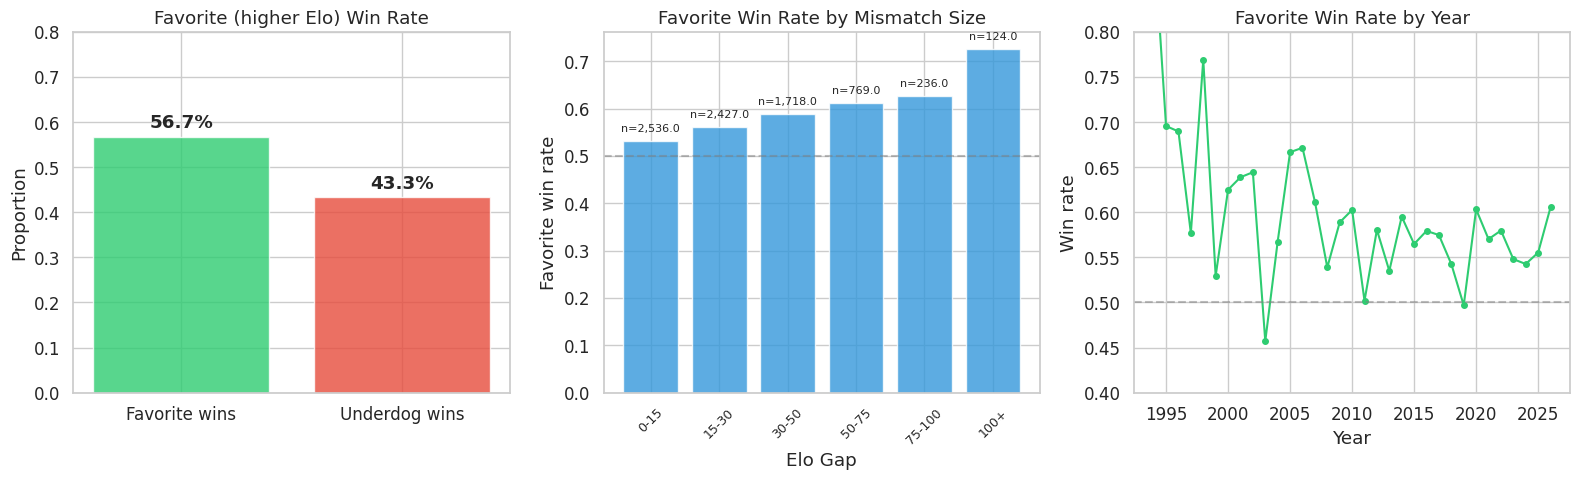

Overall favorite win rate: 56.7%
Upset rate (underdog wins): 43.3%
Big upsets (Elo gap > 75, n=360): 33.9% upset rate


In [7]:
# Define favorite: the fighter with higher Elo
# diff_elo = fighter_1_elo - fighter_2_elo
# If diff_elo > 0 → fighter_1 is favorite, label=1 means favorite won
# If diff_elo < 0 → fighter_2 is favorite, label=0 means favorite won
elo_df = df.dropna(subset=["diff_elo"]).copy()
elo_df["favorite_won"] = np.where(
    elo_df["diff_elo"] > 0,
    elo_df["label"] == 1,       # fighter_1 is favorite, did they win?
    elo_df["label"] == 0        # fighter_2 is favorite, did they win?
)
# Exclude exact ties
elo_df = elo_df[elo_df["diff_elo"] != 0]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Overall favorite win rate
fav_rate = elo_df["favorite_won"].mean()
axes[0].bar(["Favorite wins", "Underdog wins"],
            [fav_rate, 1 - fav_rate],
            color=["#2ecc71", "#e74c3c"], alpha=0.8)
axes[0].set_title("Favorite (higher Elo) Win Rate")
axes[0].set_ylabel("Proportion")
axes[0].set_ylim(0, 0.8)
for i, v in enumerate([fav_rate, 1 - fav_rate]):
    axes[0].text(i, v + 0.02, f"{100*v:.1f}%", ha="center", fontweight="bold")

# Favorite win rate by Elo gap bucket
# Bins are sized to the actual Elo gap range (max ~190 in this dataset)
elo_df["elo_gap_bucket"] = pd.cut(elo_df["abs_elo_gap"],
    bins=[0, 15, 30, 50, 75, 100, 200],
    labels=["0-15", "15-30", "30-50", "50-75", "75-100", "100+"])
bucket_stats = elo_df.groupby("elo_gap_bucket", observed=True).agg(
    fav_win_rate=("favorite_won", "mean"),
    count=("favorite_won", "count"))
axes[1].bar(range(len(bucket_stats)), bucket_stats["fav_win_rate"], color="#3498db", alpha=0.8)
axes[1].set_xticks(range(len(bucket_stats)))
axes[1].set_xticklabels(bucket_stats.index, rotation=45, fontsize=9)
axes[1].set_xlabel("Elo Gap")
axes[1].set_ylabel("Favorite win rate")
axes[1].set_title("Favorite Win Rate by Mismatch Size")
axes[1].axhline(0.5, color="gray", linestyle="--", alpha=0.5)
for i, (_, row) in enumerate(bucket_stats.iterrows()):
    axes[1].text(i, row["fav_win_rate"] + 0.02, f"n={row['count']:,}", ha="center", fontsize=8)

# Favorite win rate over time
yearly_fav = elo_df.groupby("year")["favorite_won"].mean()
axes[2].plot(yearly_fav.index, yearly_fav.values, "o-", color="#2ecc71", markersize=4)
axes[2].axhline(0.5, color="gray", linestyle="--", alpha=0.5)
axes[2].set_title("Favorite Win Rate by Year")
axes[2].set_xlabel("Year")
axes[2].set_ylabel("Win rate")
axes[2].set_ylim(0.4, 0.8)

plt.tight_layout()
plt.show()

print(f"Overall favorite win rate: {100*fav_rate:.1f}%")
print(f"Upset rate (underdog wins): {100*(1 - fav_rate):.1f}%")

# Use a threshold that has actual data (p90 ≈ 58, p95 ≈ 71)
big_upset_threshold = 75
big_upset_mask = elo_df["abs_elo_gap"] > big_upset_threshold
big_upset_n = big_upset_mask.sum()
big_upset_rate = 1 - elo_df.loc[big_upset_mask, "favorite_won"].mean()
print(f"Big upsets (Elo gap > {big_upset_threshold}, n={big_upset_n:,}): {100*big_upset_rate:.1f}% upset rate")

## 7. What Separates Winners from Losers?

Now we look at the **winner's** pre-fight stats vs the **loser's** pre-fight stats. This is the meaningful comparison — not fighter_1 vs fighter_2, but the person who actually won vs the person who lost.

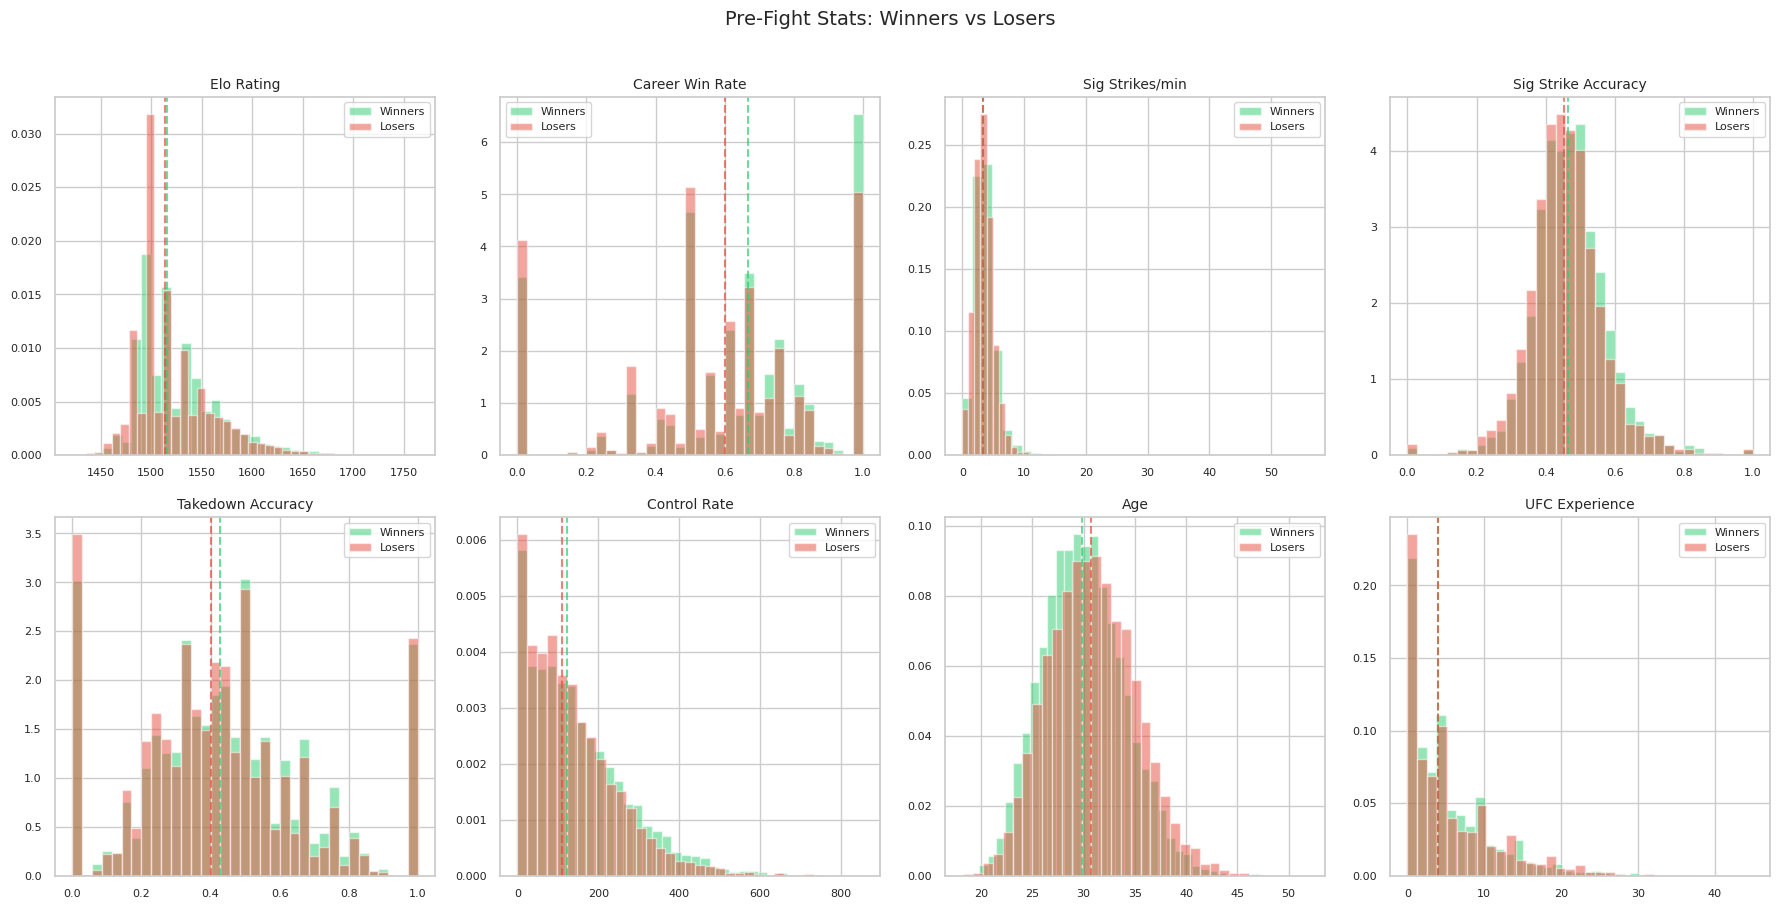

Median pre-fight stats — Winners vs Losers:
Stat                            Winners     Losers      Delta
------------------------------------------------------------
Elo Rating                      1516.03    1513.28      +2.75
Career Win Rate                    0.67       0.60      +0.07
Sig Strikes/min                    3.42       3.34      +0.08
Sig Strike Accuracy                0.47       0.45      +0.01
Takedown Accuracy                  0.43       0.40      +0.03
Control Rate                     122.62     111.27     +11.35
Age                               29.82      30.70      -0.88
UFC Experience                     4.00       4.00      +0.00


In [8]:
# Join snapshots with fight outcomes to label each snapshot as winner or loser
winner_loser = fights[["fight_id", "fighter_1_id", "fighter_2_id"]].merge(
    df[["fight_id", "label"]], on="fight_id"
)
# For each fight, determine winner_id and loser_id
winner_loser["winner_id"] = np.where(
    winner_loser["label"] == 1, winner_loser["fighter_1_id"], winner_loser["fighter_2_id"]
)
winner_loser["loser_id"] = np.where(
    winner_loser["label"] == 1, winner_loser["fighter_2_id"], winner_loser["fighter_1_id"]
)

# Join with snapshots
winner_snaps = winner_loser[["fight_id", "winner_id"]].merge(
    snapshots, left_on=["fight_id", "winner_id"], right_on=["fight_id", "fighter_id"]
).drop(columns=["fighter_id"])

loser_snaps = winner_loser[["fight_id", "loser_id"]].merge(
    snapshots, left_on=["fight_id", "loser_id"], right_on=["fight_id", "fighter_id"]
).drop(columns=["fighter_id"])

# Compare key stats
compare_cols = [
    ("elo_rating", "Elo Rating"),
    ("career_win_rate", "Career Win Rate"),
    ("career_sig_strikes_landed_pm", "Sig Strikes/min"),
    ("career_sig_strike_accuracy", "Sig Strike Accuracy"),
    ("career_takedown_accuracy", "Takedown Accuracy"),
    ("career_control_rate", "Control Rate"),
    ("age", "Age"),
    ("career_fights", "UFC Experience"),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, (col, title) in zip(axes.flat, compare_cols):
    w_data = winner_snaps[col].dropna()
    l_data = loser_snaps[col].dropna()
    ax.hist(w_data, bins=35, alpha=0.5, color="#2ecc71", label="Winners", density=True)
    ax.hist(l_data, bins=35, alpha=0.5, color="#e74c3c", label="Losers", density=True)
    ax.axvline(w_data.median(), color="#2ecc71", linestyle="--", alpha=0.7)
    ax.axvline(l_data.median(), color="#e74c3c", linestyle="--", alpha=0.7)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)
    ax.tick_params(labelsize=8)

plt.suptitle("Pre-Fight Stats: Winners vs Losers", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Print median comparisons
print("Median pre-fight stats — Winners vs Losers:")
print(f"{'Stat':<28} {'Winners':>10} {'Losers':>10} {'Delta':>10}")
print("-" * 60)
for col, title in compare_cols:
    w_med = winner_snaps[col].median()
    l_med = loser_snaps[col].median()
    delta = w_med - l_med
    print(f"{title:<28} {w_med:>10.2f} {l_med:>10.2f} {delta:>+10.2f}")

### Title fights and upsets

Do title fights behave differently? Champions are more predictable — but upsets at the highest level are the most consequential.

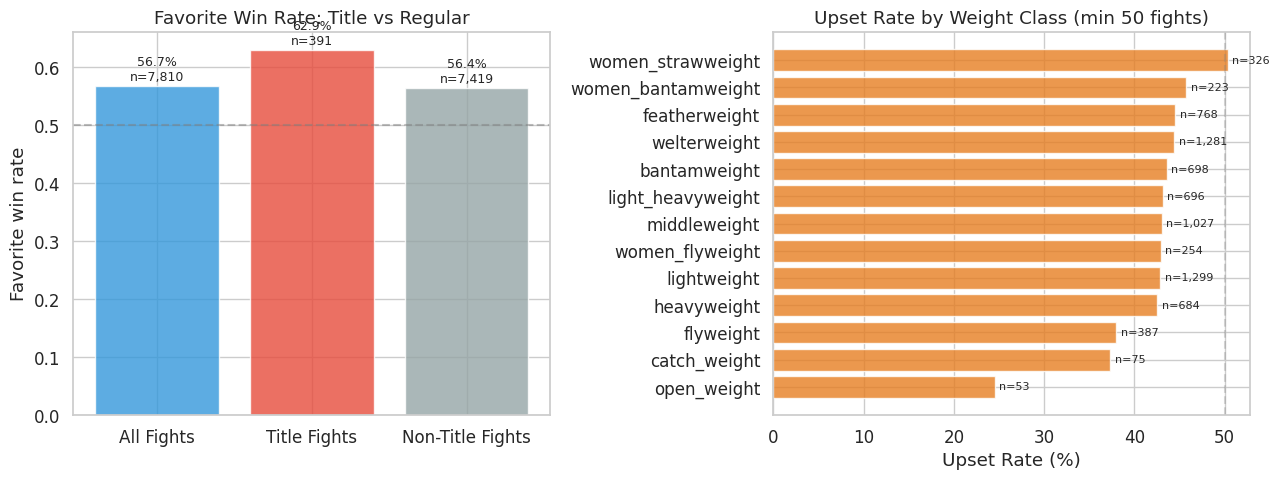

In [9]:
# Favorite win rate: title fights vs regular
title = elo_df[elo_df["is_title_fight"] == 1]
regular = elo_df[elo_df["is_title_fight"] == 0]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Title vs regular favorite win rate
categories = ["All Fights", "Title Fights", "Non-Title Fights"]
rates = [elo_df["favorite_won"].mean(), title["favorite_won"].mean(), regular["favorite_won"].mean()]
counts = [len(elo_df), len(title), len(regular)]
bars = axes[0].bar(categories, rates, color=["#3498db", "#e74c3c", "#95a5a6"], alpha=0.8)
axes[0].set_ylabel("Favorite win rate")
axes[0].set_title("Favorite Win Rate: Title vs Regular")
axes[0].axhline(0.5, color="gray", linestyle="--", alpha=0.5)
for i, (r, c) in enumerate(zip(rates, counts)):
    axes[0].text(i, r + 0.01, f"{100*r:.1f}%\nn={c:,}", ha="center", fontsize=9)

# Upset rate by weight class
wc_upsets = elo_df.groupby("weight_class").agg(
    upset_rate=("favorite_won", lambda x: 1 - x.mean()),
    count=("favorite_won", "count")
)
wc_upsets = wc_upsets[wc_upsets["count"] >= 50].sort_values("upset_rate", ascending=True)
axes[1].barh(wc_upsets.index, wc_upsets["upset_rate"] * 100, color="#e67e22", alpha=0.8)
axes[1].set_xlabel("Upset Rate (%)")
axes[1].set_title("Upset Rate by Weight Class (min 50 fights)")
axes[1].axvline(50, color="gray", linestyle="--", alpha=0.3)
for i, (wc, row) in enumerate(wc_upsets.iterrows()):
    axes[1].text(row["upset_rate"] * 100 + 0.5, i, f"n={row['count']:,.0f}", va="center", fontsize=8)

plt.tight_layout()
plt.show()

## 8. Missingness & Feature Correlations — Modeling Notes

Practical observations for the modeling pipeline.

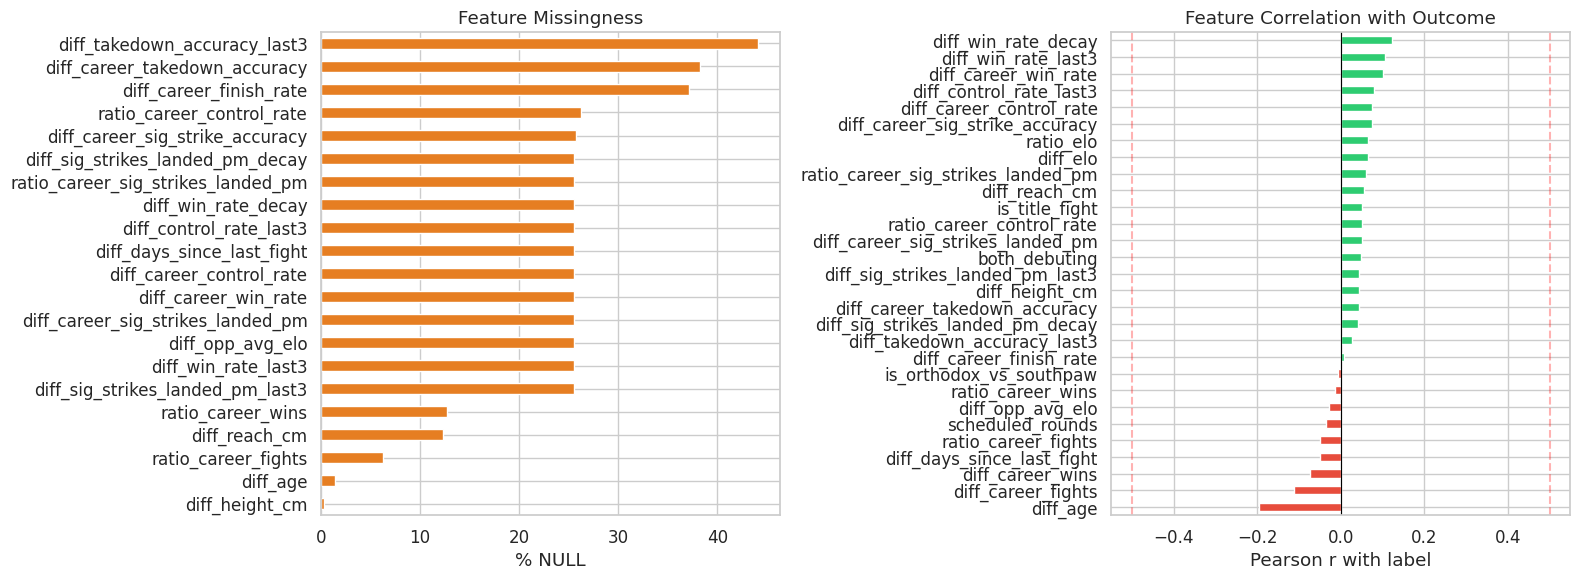

Features with 0% missing: 8 / 29
Both-debuting bouts (all diffs NULL): 530 (6.3%)

Max |r|: 0.195 (diff_age)
No features exceed |r| > 0.5 — no leakage signal.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Missingness
null_pct = df[FEATURE_COLS].isnull().mean().sort_values(ascending=False) * 100
null_pct = null_pct[null_pct > 0]
null_pct.plot.barh(ax=axes[0], color="#e67e22")
axes[0].set_xlabel("% NULL")
axes[0].set_title("Feature Missingness")
axes[0].invert_yaxis()

# Feature-to-label correlation (model features are diffs — this is valid)
numeric_feats = [c for c in FEATURE_COLS if df[c].dtype in ("float64", "int64", "Int64")]
corr_with_label = df[numeric_feats].corrwith(df["label"]).sort_values()
colors = ["#e74c3c" if v < 0 else "#2ecc71" for v in corr_with_label.values]
corr_with_label.plot.barh(ax=axes[1], color=colors)
axes[1].set_xlabel("Pearson r with label")
axes[1].set_title("Feature Correlation with Outcome")
axes[1].axvline(x=0, color="black", linewidth=0.8)
axes[1].axvline(x=0.5, color="red", linestyle="--", alpha=0.3)
axes[1].axvline(x=-0.5, color="red", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Features with 0% missing: {(df[FEATURE_COLS].isnull().mean() == 0).sum()} / {len(FEATURE_COLS)}")
print(f"Both-debuting bouts (all diffs NULL): {(df['both_debuting'] == 1).sum()} ({100*(df['both_debuting'] == 1).mean():.1f}%)")
print(f"\nMax |r|: {corr_with_label.abs().max():.3f} ({corr_with_label.abs().idxmax()})")
print("No features exceed |r| > 0.5 — no leakage signal." if corr_with_label.abs().max() < 0.5
      else "WARNING: features with |r| > 0.5 detected — check for leakage!")

## 9. Temporal Structure

Time-based splitting is essential — we never train on future fights. This shows the default split boundaries and rolling CV folds.

Split summary:
  [train 1994-03-11→2022-03-05] n=6,376  label=1: 4,264 (66.9%)  label=0: 2,112 (33.1%)
  [val 2022-03-12→2024-03-02] n=1,007  label=1: 580 (57.6%)  label=0: 427 (42.4%)
  [test 2024-03-09→2026-03-07] n=1,017  label=1: 557 (54.8%)  label=0: 460 (45.2%)


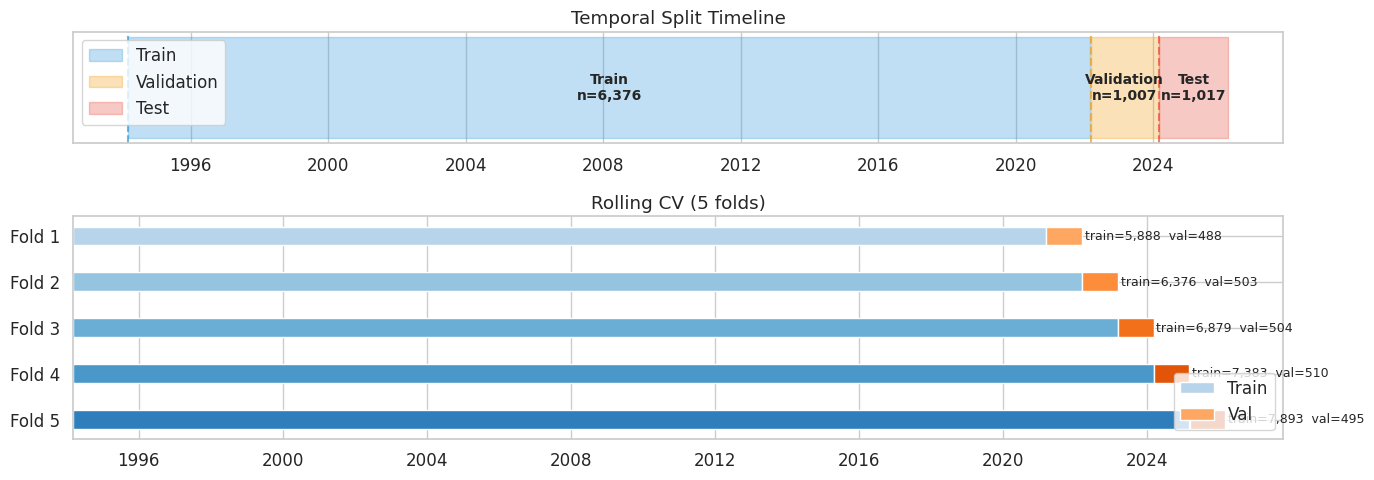

In [11]:
train, val, test = temporal_split(df)
describe_splits(train, val, test)

fig, axes = plt.subplots(2, 1, figsize=(14, 5), gridspec_kw={"height_ratios": [1, 2]})

# Train/Val/Test timeline
ax = axes[0]
for split_df, color, label in [(train, "#3498db", "Train"), (val, "#f39c12", "Validation"), (test, "#e74c3c", "Test")]:
    dates = split_df["event_date"]
    ax.fill_between([dates.min(), dates.max()], 0, 1, alpha=0.3, color=color, label=label)
    ax.axvline(x=dates.min(), color=color, linestyle="--", alpha=0.7)
    ax.text(dates.min() + (dates.max() - dates.min()) / 2, 0.5,
            f"{label}\nn={len(split_df):,}", ha="center", va="center", fontsize=10, fontweight="bold")
ax.set_yticks([])
ax.set_title("Temporal Split Timeline")
ax.legend(loc="upper left")

# Rolling CV folds
ax = axes[1]
folds = rolling_cv(df, n_folds=5, min_train_years=3, val_months=12)
colors_train = plt.cm.Blues(np.linspace(0.3, 0.7, len(folds)))
colors_val = plt.cm.Oranges(np.linspace(0.4, 0.8, len(folds)))

for i, (tr, vl) in enumerate(folds):
    y = len(folds) - i
    ax.barh(y, (tr["event_date"].max() - tr["event_date"].min()).days,
            left=tr["event_date"].min(), height=0.4, color=colors_train[i],
            label="Train" if i == 0 else None)
    ax.barh(y, (vl["event_date"].max() - vl["event_date"].min()).days,
            left=vl["event_date"].min(), height=0.4, color=colors_val[i],
            label="Val" if i == 0 else None)
    ax.text(vl["event_date"].max() + pd.Timedelta(days=30), y,
            f"train={len(tr):,}  val={len(vl):,}", va="center", fontsize=9)

ax.set_yticks(range(1, len(folds) + 1))
ax.set_yticklabels([f"Fold {len(folds) - i}" for i in range(len(folds))])
ax.set_title(f"Rolling CV ({len(folds)} folds)")
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

## 10. Takeaways for Modeling

Key observations from this exploration:

1. **The sport has evolved.** Early UFC was finish-heavy; modern UFC is more decision-oriented. Temporal splits naturally account for this — the test set reflects current conditions.

2. **Favorites win ~60% of the time**, but it scales with Elo gap. When the gap exceeds 200+ Elo points, favorites win ~70%+. This is the signal the model needs to capture — and the ceiling it can't exceed (MMA is inherently unpredictable).

3. **Winners have meaningfully higher pre-fight stats** — Elo, win rate, sig strikes, control rate all separate winners from losers. Age works in reverse (younger fighters tend to win). These are the raw signals behind the diff features.

4. **Matchmaking is fairly competitive.** Median Elo gap is modest, and most fights are reasonably close. The model mostly needs to predict outcomes in 50-150 Elo gap territory where favorites win 55-65% of the time.

5. **Missingness is structural, not random.** Debuts and sparse bios drive NULLs. LightGBM handles this natively; logistic regression needs imputation.

6. **No leakage signal.** No feature correlates with the label above |r| = 0.5. Moderate correlations (0.1-0.3) are expected and healthy.

7. **Small dataset (~8,400 rows).** Overfitting is a real risk — conservative hyperparameters and proper temporal validation are essential.

---

*Next: `02_model_comparison.ipynb` — train baselines and models, compare calibration and metrics side-by-side.*